In [ ]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [ ]:
# Load 028 transect
transect = load_transect(config.TRANSECT_028_OUTPUT)

transect.list_files()

# Select all 5 files from transect 028
cube = transect.select_files(
    [
        "rad_uhi_20241029_125028_1",
        "rad_uhi_20241029_125028_2",
        "rad_uhi_20241029_125028_3",
        "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
# cube.describe()

In [ ]:
# Apply illumination correction
cube.apply_illumination_correction_v2()

In [ ]:
cube.apply_spectral_smoothing(method="gaussian", gaussian_sigma=5.0)

In [ ]:
cube.apply_wavelength_filter(wavelength_range=(490, 700))

In [ ]:
cube.apply_spectral_normalization(method="l2")

In [ ]:
def plot_multiple_crops(
    cube,
    crop_regions,
    wavelength_target=660,
    derivative_order=0,
    derivative_window=2,
    crop_width=500,
    crop_aspect_ratio=4,
    display_aspect_ratio=4.0,
    vmin=0.086,
    vmax=0.1,
    use_wavelength_colormap=True,
    flip_axes=True,
    flip_horizontal=True,
    show_file_boundaries=False,
    use_corrected=True,
    display_only_image=False,  # NEW: Remove all axes/colorbar/labels
    save_file=None,  # NEW: Path to save (with extension, e.g., "bomb1_677nm.pdf")
    **kwargs,
):
    """
    Plot multiple crop regions with the same settings.

    NEW PARAMETERS:
        display_only_image: If True, hide axes/colorbar/labels/title (clean image only)
        save_file: If provided, save to this path. Extension determines format.
                   Format: "path/filename_{label}.ext" where {label} replaced with region label
                   If no {label} placeholder, all regions saved to same file (last overwrites)

    Example:
        crop_regions = [
            {"track": 1258, "slit": 250, "label": "Bomb 2"},
            {"track": 5592, "slit": 700, "label": "Bomb 3"},
        ]

        # Display with axes/colorbar
        plot_multiple_crops(cube, crop_regions, wavelength_target=660)

        # Clean images only, no save
        plot_multiple_crops(cube, crop_regions, display_only_image=True)

        # Clean images, save each crop
        plot_multiple_crops(
            cube, crop_regions,
            display_only_image=True,
            save_file="output/bomb_{label}_677nm.pdf"
        )
    """
    import matplotlib.pyplot as plt
    from pathlib import Path

    print(f"📊 Plotting {len(crop_regions)} regions...")
    print(f"   Wavelength: {wavelength_target} nm, Derivative: {derivative_order}")
    print(f"   Normalization: vmin={vmin}, vmax={vmax}")
    if display_only_image:
        print(f"   Mode: Clean image only (no axes/colorbar)")
    if save_file:
        print(f"   Saving to: {save_file}")
    print()

    for i, region in enumerate(crop_regions, 1):
        label = region.get("label", f"Region {i}")
        print(
            f"[{i}/{len(crop_regions)}] {label}: track={region['track']}, slit={region['slit']}"
        )

        # Monkeypatch plt.show() to intercept and do cleanup first
        _original_show = plt.show

        def _cleanup_then_show(*args, **kwargs):
            """Intercepts plt.show(), does cleanup if needed, then shows"""
            if display_only_image:
                fig = plt.gcf()
                ax = fig.axes[
                    0
                ]  # FIXED: Get main image axes (not current, which might be colorbar)

                # Remove all axes, ticks, labels
                ax.axis("off")

                # Remove colorbar if exists (it's in additional axes)
                if len(fig.axes) > 1:
                    for a in fig.axes[1:]:
                        a.remove()

                # Remove any titles
                ax.set_title("")
                fig.suptitle("")

                # Tight layout with no padding
                plt.subplots_adjust(
                    left=0, right=1, top=1, bottom=0, wspace=0, hspace=0
                )

            # Save if requested (before showing)
            if save_file:
                # Replace {label} placeholder with actual label
                save_path = save_file.replace("{label}", label.replace(" ", "_"))
                save_path = Path(save_path)

                # Create directory if needed
                save_path.parent.mkdir(parents=True, exist_ok=True)

                # Save with tight bounding box and no padding
                plt.savefig(
                    save_path,
                    bbox_inches="tight",
                    pad_inches=0,
                )
                print(f"   ✅ Saved: {save_path}")

            # Now actually show
            _original_show(*args, **kwargs)

        # Apply temporary monkeypatch
        plt.show = _cleanup_then_show

        try:
            # Call plot_rgb - it will call our patched show() which does cleanup first
            cube.plot_rgb(
                use_corrected=use_corrected,
                figsize=(30, 8.32),
                flip_axes=flip_axes,
                flip_horizontal=flip_horizontal,
                crop_center_track=region["track"],
                crop_center_slit=region["slit"],
                crop_width=crop_width,
                show_file_boundaries=show_file_boundaries,
                crop_aspect_ratio=crop_aspect_ratio,
                display_aspect_ratio=display_aspect_ratio,
                use_wavelength_colormap=use_wavelength_colormap,
                wavelength_colormap_target=wavelength_target,
                derivative_order=derivative_order,
                derivative_window=derivative_window,
                vmin=vmin,
                vmax=vmax,
                **kwargs,
            )
        finally:
            # Restore original show
            plt.show = _original_show

    print(f"\n✅ All {len(crop_regions)} regions plotted!")

In [ ]:
# 🔧 MONKEYPATCH: Add colorbar orientation support to plot_rgb
# This allows horizontal/vertical colorbar control without kernel restart

import matplotlib.pyplot as plt

# Store the original colorbar function
_original_colorbar = plt.colorbar


def colorbar_with_orientation(*args, **kwargs):
    """
    Wrapper that intercepts colorbar calls and adds orientation support.

    Looks for 'colorbar_orientation' in kwargs and converts it to 'orientation'.
    This allows us to pass colorbar_orientation through **kwargs in plot_multiple_crops!
    """
    # Extract colorbar_orientation if present, default to 'vertical'
    if "colorbar_orientation" in kwargs:
        orientation = kwargs.pop("colorbar_orientation")
        kwargs["orientation"] = orientation
    elif "orientation" not in kwargs:
        kwargs["orientation"] = "vertical"

    return _original_colorbar(*args, **kwargs)


# Apply monkeypatch
plt.colorbar = colorbar_with_orientation

print("✅ Colorbar monkeypatched with orientation support!")
print("   You can now use 'colorbar_orientation' parameter in plot_multiple_crops")
print()
print("💡 Usage examples:")
print("   # Horizontal colorbar:")
print("   plot_multiple_crops(cube, regions, colorbar_orientation='horizontal',")
print("                       colorbar_fraction=0.03, colorbar_pad=0.1)")
print()
print("   # Vertical colorbar (default):")
print("   plot_multiple_crops(cube, regions, colorbar_orientation='vertical',")
print("                       colorbar_fraction=0.006)")

In [ ]:
# 🎨 MONKEYPATCH V2: Non-linear colormap with slow transitions at ends
# Uses a power curve to compress color changes at low/high values
# and expand them in the middle for better contrast

from matplotlib.colors import LinearSegmentedColormap
from utils.ndi_analysis_utils import wavelength_to_rgb
import utils.ndi_analysis_utils as ndi_utils
import numpy as np


def create_wavelength_colormap_nonlinear(wavelength, darkness_factor=0.3):
    """
    NON-LINEAR VERSION: Create a colormap with perceptually better distribution

    Uses a power curve (x^2.5) to create:
    - Slow transition at low values (stays white longer)
    - Fast transition in middle (good contrast)
    - Slow transition at high values (gradual to dark)

    This gives better visual accuracy for identifying features!
    """
    # Get the RGB color for this wavelength
    wl_rgb = wavelength_to_rgb(wavelength)

    # Create color stops
    white = (1.0, 1.0, 1.0)
    light_color = tuple((c + 2 * 1.0) / 3 for c in wl_rgb)  # Mix 1/3 color + 2/3 white
    bright_color = wl_rgb
    dark_color = tuple(c * darkness_factor for c in wl_rgb)

    # Create many positions using a power curve for non-linear mapping
    # x^2.5 compresses the ends and expands the middle
    n_points = 100
    linear_positions = np.linspace(0, 1, n_points)

    # Apply power curve: x^2.5 gives good balance
    # Lower exponent (2.0) = more linear
    # Higher exponent (3.0) = more contrast in middle
    power = 2.5
    nonlinear_positions = linear_positions**power

    # Interpolate colors based on non-linear positions
    colors_interp = []
    for pos in nonlinear_positions:
        if pos < 0.4:
            # White to light color (40% of range)
            alpha = pos / 0.4
            color = tuple(
                w * (1 - alpha) + l * alpha for w, l in zip(white, light_color)
            )
        elif pos < 0.7:
            # Light to bright (30% of range)
            alpha = (pos - 0.4) / 0.3
            color = tuple(
                l * (1 - alpha) + b * alpha for l, b in zip(light_color, bright_color)
            )
        else:
            # Bright to dark (30% of range)
            alpha = (pos - 0.7) / 0.3
            color = tuple(
                b * (1 - alpha) + d * alpha for b, d in zip(bright_color, dark_color)
            )
        colors_interp.append(color)

    # Create colormap with all interpolated colors
    cmap = LinearSegmentedColormap.from_list(
        f"wl_{wavelength}nm_nonlinear",
        list(zip(linear_positions, colors_interp)),
        N=256,
    )

    return cmap


# Replace the function with non-linear version
ndi_utils.create_wavelength_colormap = create_wavelength_colormap_nonlinear

print("✅ Wavelength colormap function patched with NON-LINEAR scaling!")
print("   Power curve (x^2.5) applied for better perceptual accuracy")
print("   - Slow transitions at low values (more white, less noise)")
print("   - Fast transitions in middle (good feature contrast)")
print("   - Slow transitions at high values (gradual saturation)")
print("\n💡 Adjust 'power' variable in cell to tweak (2.0=linear, 3.0=more contrast)")

In [ ]:
# 🧪 TEST: Re-plot with NON-LINEAR colormap
# This is a copy of cell 8 for quick testing with the power curve

# Define your crop regions once
crop_regions = [
    {"track": 5160, "slit": 613, "label": "a"},
    {"track": 1258, "slit": 250, "label": "b"},
    {"track": 5592, "slit": 700, "label": "c"},
    {"track": 717, "slit": 385, "label": "d"},
    {"track": 4026, "slit": 582, "label": "e"},
]

# Plot all regions with NON-LINEAR colormap (power curve = 2.5)
plot_multiple_crops(
    cube,
    crop_regions,
    crop_width=500,
    derivative_order=0,
    vmin=0.086,
    vmax=0.108,
    wavelength_target=677,
    colorbar_orientation="horizontal",  # ⬅️ HORIZONTAL!
    colorbar_fraction=0.05,  # Height (taller for horizontal)
    colorbar_pad=0.1,  # Space below plot
    display_only_image=True,
    save_file="../images_for_publication/greyscale/028/{label}_677nm.pdf",
)

plot_multiple_crops(
    cube,
    crop_regions,
    crop_width=500,
    derivative_order=1,
    vmin=-0.000365,
    vmax=0.000427,
    wavelength_target=660,
    colorbar_orientation="horizontal",  # ⬅️ HORIZONTAL!
    colorbar_fraction=0.05,  # Height (taller for horizontal)
    colorbar_pad=0.1,  # Space below plot
    display_only_image=True,
    save_file="../images_for_publication/greyscale/028/{label}_660nm_derivative.pdf",
)

plot_multiple_crops(
    cube,
    crop_regions,
    crop_width=500,
    derivative_order=0,
    vmin=0.0793,
    vmax=0.105,
    wavelength_target=490,
    colorbar_orientation="horizontal",  # ⬅️ HORIZONTAL!
    colorbar_fraction=0.05,  # Height (taller for horizontal)
    colorbar_pad=0.1,  # Space below plot
    display_only_image=True,
    save_file="../images_for_publication/greyscale/028/{label}_490nm.pdf",
)

plot_multiple_crops(
    cube,
    crop_regions,
    crop_width=500,
    derivative_order=0,
    vmin=0.0855,
    vmax=0.095,
    wavelength_target=610,
    colorbar_orientation="horizontal",  # ⬅️ HORIZONTAL!
    colorbar_fraction=0.05,  # Height (taller for horizontal)
    colorbar_pad=0.1,  # Space below plot
    display_only_image=True,
    save_file="../images_for_publication/greyscale/028/{label}_610nm.pdf",
)

plot_multiple_crops(
    cube,
    crop_regions,
    crop_width=500,
    derivative_order=0,
    # vmin=0.0855,
    # vmax=0.095,
    wavelength_target=500,
    colorbar_orientation="horizontal",  # ⬅️ HORIZONTAL!
    colorbar_fraction=0.05,  # Height (taller for horizontal)
    colorbar_pad=0.1,  # Space below plot
    display_only_image=True,
    save_file="../images_for_publication/greyscale/028/{label}_500nm.pdf",
)

In [ ]:
# get the scale bar


plot_multiple_crops(
    cube,
    crop_regions,
    crop_width=500,
    derivative_order=0,
    vmin=0.086,
    vmax=0.108,
    wavelength_target=677,
    colorbar_orientation="horizontal",  # ⬅️ HORIZONTAL!
    colorbar_fraction=0.05,  # Height (taller for horizontal)
    colorbar_pad=0.1,  # Space below plot
    display_only_image=False,
    save_file="../images_for_publication/greyscale/028/scalebar_677.pdf",
)

plot_multiple_crops(
    cube,
    crop_regions,
    crop_width=500,
    derivative_order=1,
    vmin=-0.000365,
    vmax=0.000427,
    wavelength_target=660,
    colorbar_orientation="horizontal",
    colorbar_fraction=0.05,
    colorbar_pad=0.1,
    display_only_image=False,
    save_file="../images_for_publication/greyscale/028/scalebar_660_derivative.pdf",
)

plot_multiple_crops(
    cube,
    crop_regions,
    crop_width=500,
    derivative_order=0,
    vmin=0.0793,
    vmax=0.105,
    wavelength_target=490,
    colorbar_orientation="horizontal",
    colorbar_fraction=0.05,
    colorbar_pad=0.1,
    display_only_image=False,
    save_file="../images_for_publication/greyscale/028/scalebar_490.pdf",
)

plot_multiple_crops(
    cube,
    crop_regions,
    crop_width=500,
    derivative_order=0,
    vmin=0.0855,
    vmax=0.095,
    wavelength_target=610,
    colorbar_orientation="horizontal",
    colorbar_fraction=0.05,
    colorbar_pad=0.1,
    display_only_image=False,
    save_file="../images_for_publication/greyscale/028/scalebar_610.pdf",
)

plot_multiple_crops(
    cube,
    crop_regions,
    crop_width=500,
    derivative_order=0,
    wavelength_target=500,
    colorbar_orientation="horizontal",
    colorbar_fraction=0.05,
    colorbar_pad=0.1,
    display_only_image=False,
    save_file="../images_for_publication/greyscale/028/scalebar_500.pdf",
)

In [ ]:
# 🧪 More examples with different orientations

# Example 2: Thick VERTICAL colorbar (right side)
# plot_multiple_crops(
#     cube,
#     [{"track": 1258, "slit": 250, "label": "Bomb 2"}],
#     crop_width=500,
#     derivative_order=0,
#     vmin=0.086,
#     vmax=0.108,
#     wavelength_target=677,
#     colorbar_orientation="vertical",  # ⬅️ VERTICAL (default)
#     colorbar_fraction=0.02,  # Width (thicker)
#     colorbar_shrink=1.0,  # Full height
# )

# Example 3: Compare derivative with horizontal colorbar
# plot_multiple_crops(
#     cube,
#     crop_regions,
#     crop_width=500,
#     derivative_order=1,  # First derivative
#     vmin=-0.000365,
#     vmax=0.000427,
#     wavelength_target=660,
#     colorbar_orientation="horizontal",
#     colorbar_fraction=0.025,
#     colorbar_pad=0.08,
# )

---

---

---

---

---

---

---

---

# greyscale for 057


In [ ]:
stop

In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [2]:
# ========== TRANSECT 057 (DEFAULT) ==========
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file from transect 057
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
Spectral bands: 210
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📊 Spectral configuration:
   Wavelength range: 380.9 -

In [3]:
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [4]:
cube.apply_spectral_smoothing(method="gaussian", gaussian_sigma=5.0)

💾 Found cached smoothing (gaussian, corrected data) - loading from disk (much faster!)
📂 Loading saved spectral smoothing (gaussian, corrected data) from 1 files...
   rad_uhi_20241029_115057_5: method=gaussian
✅ Loaded spectral smoothing from disk (saved computation time!)


array([[[  1.4053802 ,   1.2650696 ,   1.1382263 , ...,   1.1283655 ,
           0.97737503,   0.83948207],
        [  4.6651793 ,   4.2503104 ,   3.8811233 , ...,   1.1326705 ,
           0.9723464 ,   0.8175835 ],
        [  1.3719033 ,   1.2897086 ,   1.2119116 , ...,   1.8223882 ,
           1.5475298 ,   1.2971877 ],
        ...,
        [  1.3580438 ,   1.3156981 ,   1.2867721 , ...,   0.56639993,
           0.4903108 ,   0.43773448],
        [  3.5521085 ,   3.1614618 ,   2.791659  , ...,   1.3441232 ,
           1.1704057 ,   0.9949217 ],
        [  1.6943413 ,   1.6141984 ,   1.5584607 , ...,   2.2617679 ,
           2.1754954 ,   2.0517063 ]],

       [[  2.318576  ,   2.3062904 ,   2.2812638 , ...,   1.101198  ,
           0.9108031 ,   0.7313268 ],
        [  2.301428  ,   2.3859735 ,   2.4506774 , ...,   1.2345957 ,
           1.1081169 ,   0.99427783],
        [  2.7406316 ,   3.0454702 ,   3.413178  , ...,   1.9089841 ,
           1.5757452 ,   1.2690792 ],
        ...,


In [5]:
cube.apply_wavelength_filter(wavelength_range=(490, 700))

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-700 nm
✂️  Filtered wavelengths: 119
📉 Range: 490.2 - 699.4 nm

✅ Datacube shape after filtering: (2462, 968, 119)
   Memory: 1.06 GB


array([[[1.0242817 , 1.0233774 , 1.0235972 , ..., 1.0452163 ,
         1.0459423 , 1.047293  ],
        [1.0548365 , 1.0539597 , 1.0523418 , ..., 1.0706059 ,
         1.0636694 , 1.0545129 ],
        [1.0433822 , 1.0478745 , 1.0514694 , ..., 1.0309559 ,
         1.0289329 , 1.0286332 ],
        ...,
        [1.0650878 , 1.0582087 , 1.0508734 , ..., 1.0319183 ,
         1.0231724 , 1.0166652 ],
        [1.0264505 , 1.0296129 , 1.03321   , ..., 1.0880054 ,
         1.0686986 , 1.0491787 ],
        [1.0137969 , 1.0122609 , 1.0117648 , ..., 1.0593293 ,
         1.0531667 , 1.0422413 ]],

       [[1.0191454 , 1.0156488 , 1.0118141 , ..., 1.091157  ,
         1.0910306 , 1.0903581 ],
        [1.0168545 , 1.0150243 , 1.0127909 , ..., 1.0194405 ,
         1.0147187 , 1.0108873 ],
        [1.059358  , 1.0585549 , 1.057203  , ..., 1.0557945 ,
         1.0621332 , 1.0710251 ],
        ...,
        [1.0225906 , 1.0255002 , 1.0263999 , ..., 1.1815886 ,
         1.2010847 , 1.2249782 ],
        [1.0

In [6]:
cube.apply_spectral_normalization(method="l2")

📐 SPECTRAL NORMALIZATION: L2
📊 Datacube shape: (2462, 968, 119)
🌊 Wavelengths: 119 (490.2 - 699.4 nm)

✅ Normalization complete!
   Method: l2
   Value range: [0.0491, 0.2558]


array([[[0.09028508, 0.09020536, 0.09022474, ..., 0.09213036,
         0.09219434, 0.09231339],
        [0.09283269, 0.09275553, 0.09261314, ..., 0.0942205 ,
         0.09361005, 0.09280421],
        [0.09254118, 0.09293962, 0.09325847, ..., 0.09143905,
         0.09125963, 0.09123304],
        ...,
        [0.09357563, 0.09297125, 0.09232679, ..., 0.09066145,
         0.08989306, 0.08932136],
        [0.0896493 , 0.0899255 , 0.09023967, ..., 0.09502545,
         0.09333921, 0.09163436],
        [0.08905125, 0.08891633, 0.08887275, ..., 0.09305079,
         0.09250947, 0.09154979]],

       [[0.09069894, 0.09038776, 0.09004649, ..., 0.09710761,
         0.09709636, 0.09703652],
        [0.09105408, 0.0908902 , 0.09069021, ..., 0.09128565,
         0.09086283, 0.09051975],
        [0.09491789, 0.09484593, 0.0947248 , ..., 0.0945986 ,
         0.09516654, 0.09596325],
        ...,
        [0.08862379, 0.08887596, 0.08895393, ..., 0.10240351,
         0.10409316, 0.10616391],
        [0.0

In [7]:
# 🎨 APPLY POWER CURVE COLORMAP for Transect 057
# Re-run the monkeypatch to ensure non-linear colormap is active

from matplotlib.colors import LinearSegmentedColormap
from utils.ndi_analysis_utils import wavelength_to_rgb
import utils.ndi_analysis_utils as ndi_utils
import numpy as np


def create_wavelength_colormap_nonlinear(wavelength, darkness_factor=0.3):
    """
    NON-LINEAR VERSION: Create a colormap with perceptually better distribution

    Uses a power curve (x^2.5) to create:
    - Slow transition at low values (stays white longer)
    - Fast transition in middle (good contrast)
    - Slow transition at high values (gradual to dark)

    This gives better visual accuracy for identifying features!
    """
    # Get the RGB color for this wavelength
    wl_rgb = wavelength_to_rgb(wavelength)

    # Create color stops
    white = (1.0, 1.0, 1.0)
    light_color = tuple((c + 2 * 1.0) / 3 for c in wl_rgb)  # Mix 1/3 color + 2/3 white
    bright_color = wl_rgb
    dark_color = tuple(c * darkness_factor for c in wl_rgb)

    # Create many positions using a power curve for non-linear mapping
    # x^2.5 compresses the ends and expands the middle
    n_points = 100
    linear_positions = np.linspace(0, 1, n_points)

    # Apply power curve: x^2.5 gives good balance
    # Lower exponent (2.0) = more linear
    # Higher exponent (3.0) = more contrast in middle
    power = 2.5
    nonlinear_positions = linear_positions**power

    # Interpolate colors based on non-linear positions
    colors_interp = []
    for pos in nonlinear_positions:
        if pos < 0.4:
            # White to light color (40% of range)
            alpha = pos / 0.4
            color = tuple(
                w * (1 - alpha) + l * alpha for w, l in zip(white, light_color)
            )
        elif pos < 0.7:
            # Light to bright (30% of range)
            alpha = (pos - 0.4) / 0.3
            color = tuple(
                l * (1 - alpha) + b * alpha for l, b in zip(light_color, bright_color)
            )
        else:
            # Bright to dark (30% of range)
            alpha = (pos - 0.7) / 0.3
            color = tuple(
                b * (1 - alpha) + d * alpha for b, d in zip(bright_color, dark_color)
            )
        colors_interp.append(color)

    # Create colormap with all interpolated colors
    cmap = LinearSegmentedColormap.from_list(
        f"wl_{wavelength}nm_nonlinear",
        list(zip(linear_positions, colors_interp)),
        N=256,
    )

    return cmap


# Replace the function with non-linear version
ndi_utils.create_wavelength_colormap = create_wavelength_colormap_nonlinear

print("✅ Power curve colormap (x^2.5) applied for transect 057!")
print("   - Slow transitions at low values (stays white longer)")
print("   - Fast transitions in middle (better contrast)")
print("   - Slow transitions at high values (gradual darkening)")

✅ Power curve colormap (x^2.5) applied for transect 057!
   - Slow transitions at low values (stays white longer)
   - Fast transitions in middle (better contrast)
   - Slow transitions at high values (gradual darkening)


In [ ]:
# 🎨 HELPER: Clean georef image saver
# Wrapper to save plot_georef output without axes/colorbar/labels

import matplotlib.pyplot as plt
from pathlib import Path


def plot_georef_clean(
    cube,
    wavelength_target,
    save_folder,
    derivative_order=0,
    vmin=None,
    vmax=None,
    display_only_image=True,
    **georef_kwargs,
):
    """
    Plot georeferenced image with optional clean output (no axes/colorbar).

    Parameters:
        cube: CombinedTransectCube object
        wavelength_target: Target wavelength in nm (used for colormap and filename)
        save_folder: Folder to save images (e.g., "../images_for_publication/greyscale/057")
        derivative_order: 0 (raw), 1 (gradient), 2 (laplacian)
        vmin, vmax: Color scale limits
        display_only_image: If True, remove axes/colorbar/labels
        **georef_kwargs: Additional arguments passed to plot_georef
    """

    # Build filename
    filename = f"{wavelength_target}nm"
    if derivative_order > 0:
        filename += f"_derivative{derivative_order}"
    filename += ".pdf"

    save_path = Path(save_folder) / filename

    # Monkeypatch plt.show() to intercept and do cleanup first
    _original_show = plt.show

    def _cleanup_then_show(*args, **kwargs):
        """Intercepts plt.show(), does cleanup if needed, then shows"""
        if display_only_image:
            fig = plt.gcf()
            ax = fig.axes[0]  # Main image axes

            # Remove all axes, ticks, labels
            ax.axis("off")

            # Remove colorbar if exists (it's in additional axes)
            if len(fig.axes) > 1:
                for a in fig.axes[1:]:
                    a.remove()

            # Remove any titles
            ax.set_title("")
            fig.suptitle("")

            # Tight layout with no padding
            plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

        # Save if path provided
        if save_path:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
            print(f"✅ Saved: {save_path}")

        # Now actually show
        _original_show(*args, **kwargs)

    # Apply temporary monkeypatch
    plt.show = _cleanup_then_show

    try:
        # Call plot_georef - it will call our patched show() which does cleanup first
        cube.plot_georef(
            use_corrected=True,
            use_wavelength_colormap=True,
            wavelength_colormap_target=wavelength_target,
            derivative_order=derivative_order,
            vmin=vmin,
            vmax=vmax,
            quiet=False,
            **georef_kwargs,
        )
    finally:
        # Restore original show
        plt.show = _original_show


print("✅ plot_georef_clean() function defined!")
print(
    "   Usage: plot_georef_clean(cube, wavelength_target=677, save_folder='greyscale/057')"
)

In [8]:
# 677 nm - Clean image save
plot_georef_clean(
    cube,
    wavelength_target=677,
    save_folder="../images_for_publication/greyscale/057",
    derivative_order=0,
    vmin=0.086,
    vmax=0.1,
    display_only_image=True,
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
)

NameError: name 'plot_georef_clean' is not defined

🔧 DEBUG: plot_georef called with use_wavelength_colormap=True, wavelength_colormap_target=677
💡 Interactive mode: Click on the plot to display coordinates


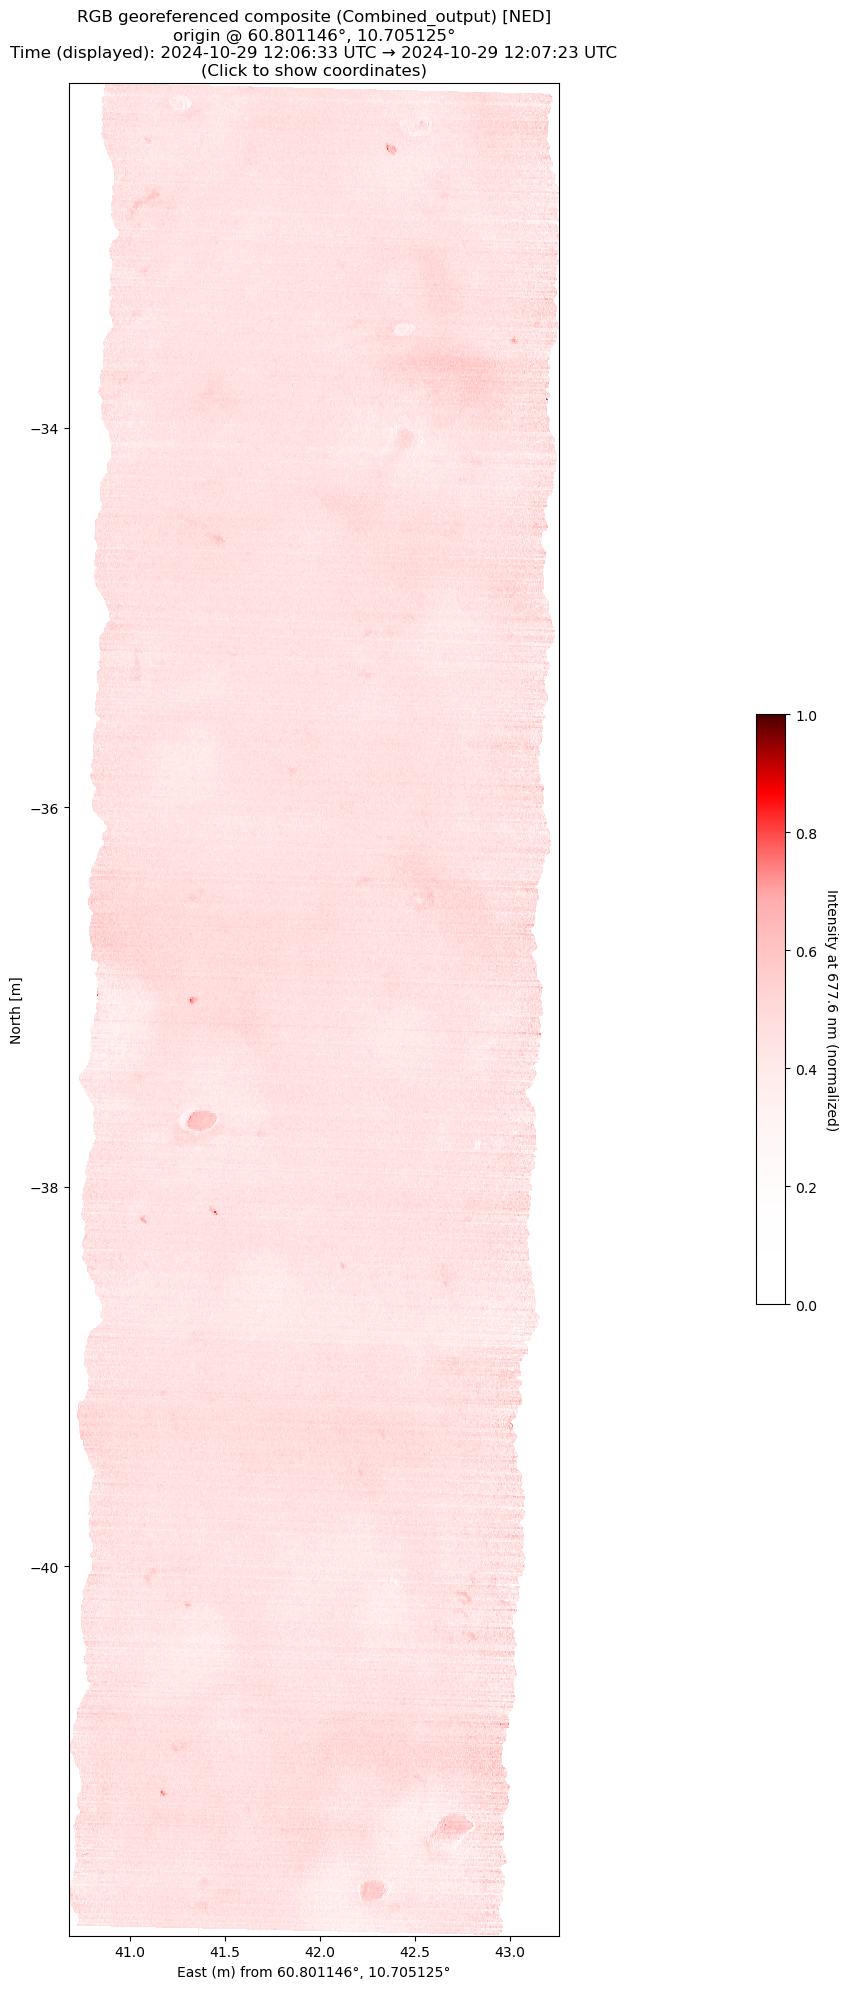

In [ ]:
# cube.plot_georef(
#     use_corrected=True,
#     track_start=config.UHI_TRACK_RANGE[0],
#     track_end=config.UHI_TRACK_RANGE[1],
#     use_wavelength_colormap=True,
#     wavelength_colormap_target=677,
#     # vmin=0.09,
#     # vmax=0.15,
#     # make it use the same minmax as the other greyscales
#     # vmin=0.086,
#     # vmax=0.1,
#     # Let it auto-compute to see actual data range
#     colorbar_fraction=0.006,  # Width
#     colorbar_pad=0.04,  # Padding (now works!)
#     colorbar_shrink=0.5,  # Height (now works!)
#     figsize=(50, 20),
# )

🔧 DEBUG: plot_georef called with use_wavelength_colormap=True, wavelength_colormap_target=660
💡 Interactive mode: Click on the plot to display coordinates


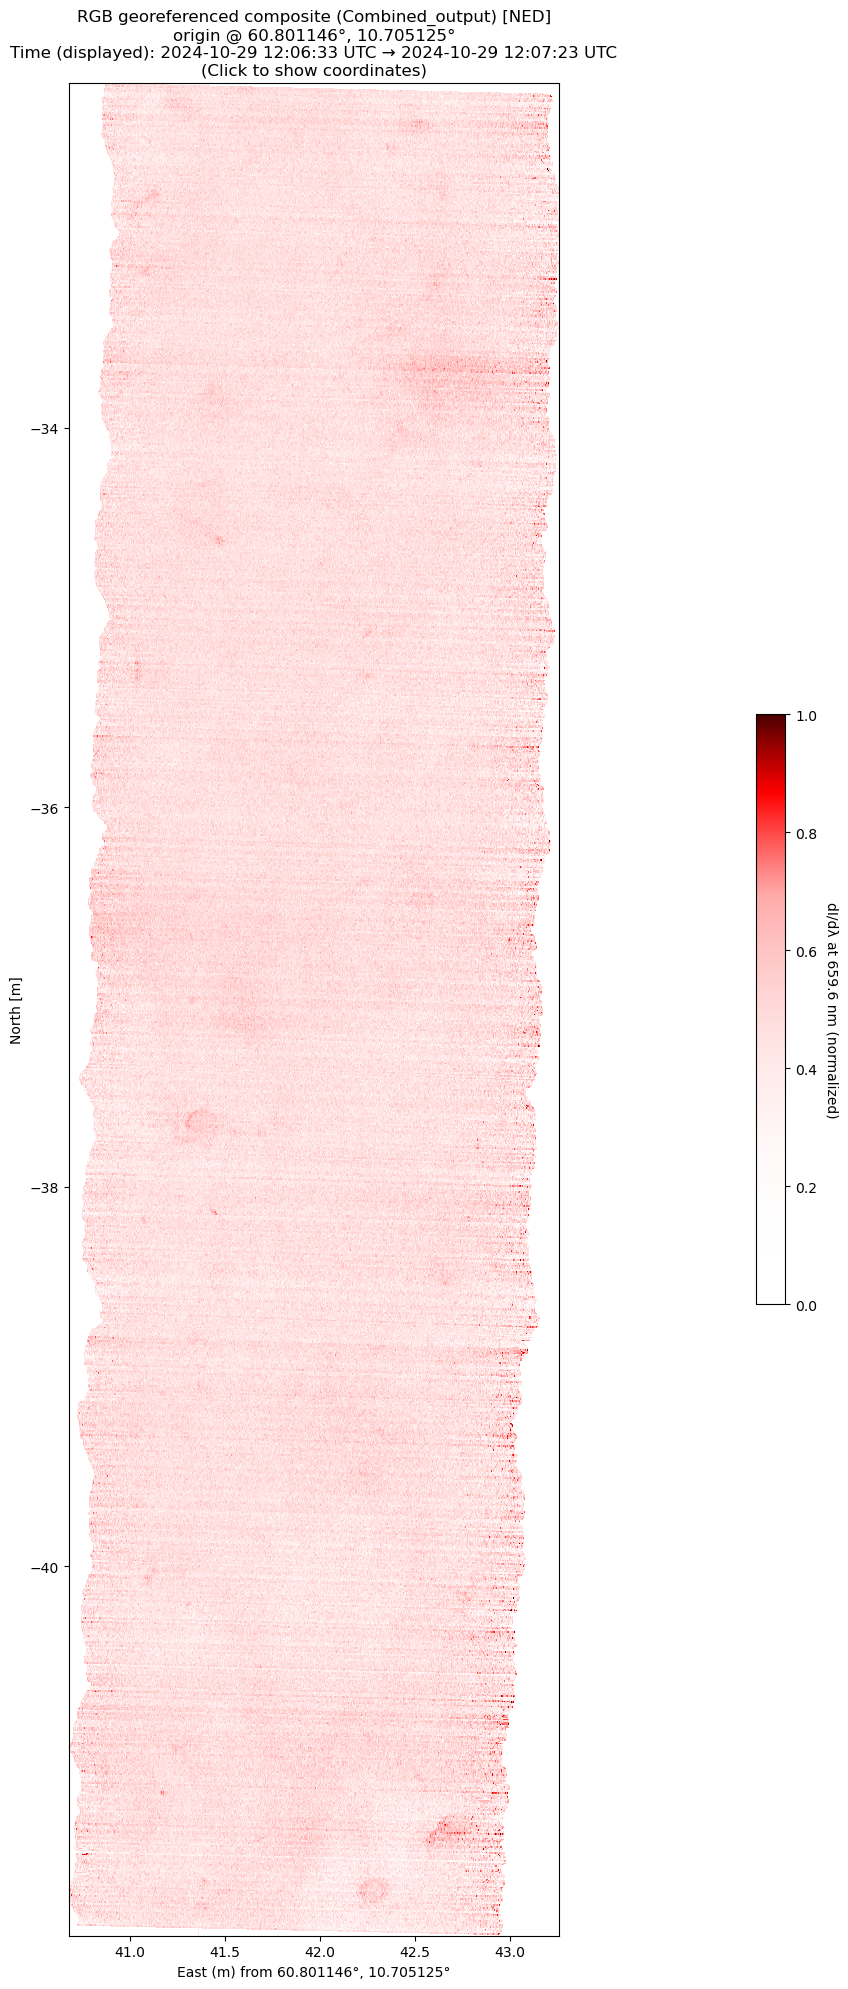

In [ ]:
# 660 nm derivative - Clean image save
plot_georef_clean(
    cube,
    wavelength_target=660,
    save_folder="../images_for_publication/greyscale/057",
    derivative_order=1,
    vmin=-0.000365,
    vmax=0.000427,
    display_only_image=True,
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
)

🔧 DEBUG: plot_georef called with use_wavelength_colormap=True, wavelength_colormap_target=490
💡 Interactive mode: Click on the plot to display coordinates


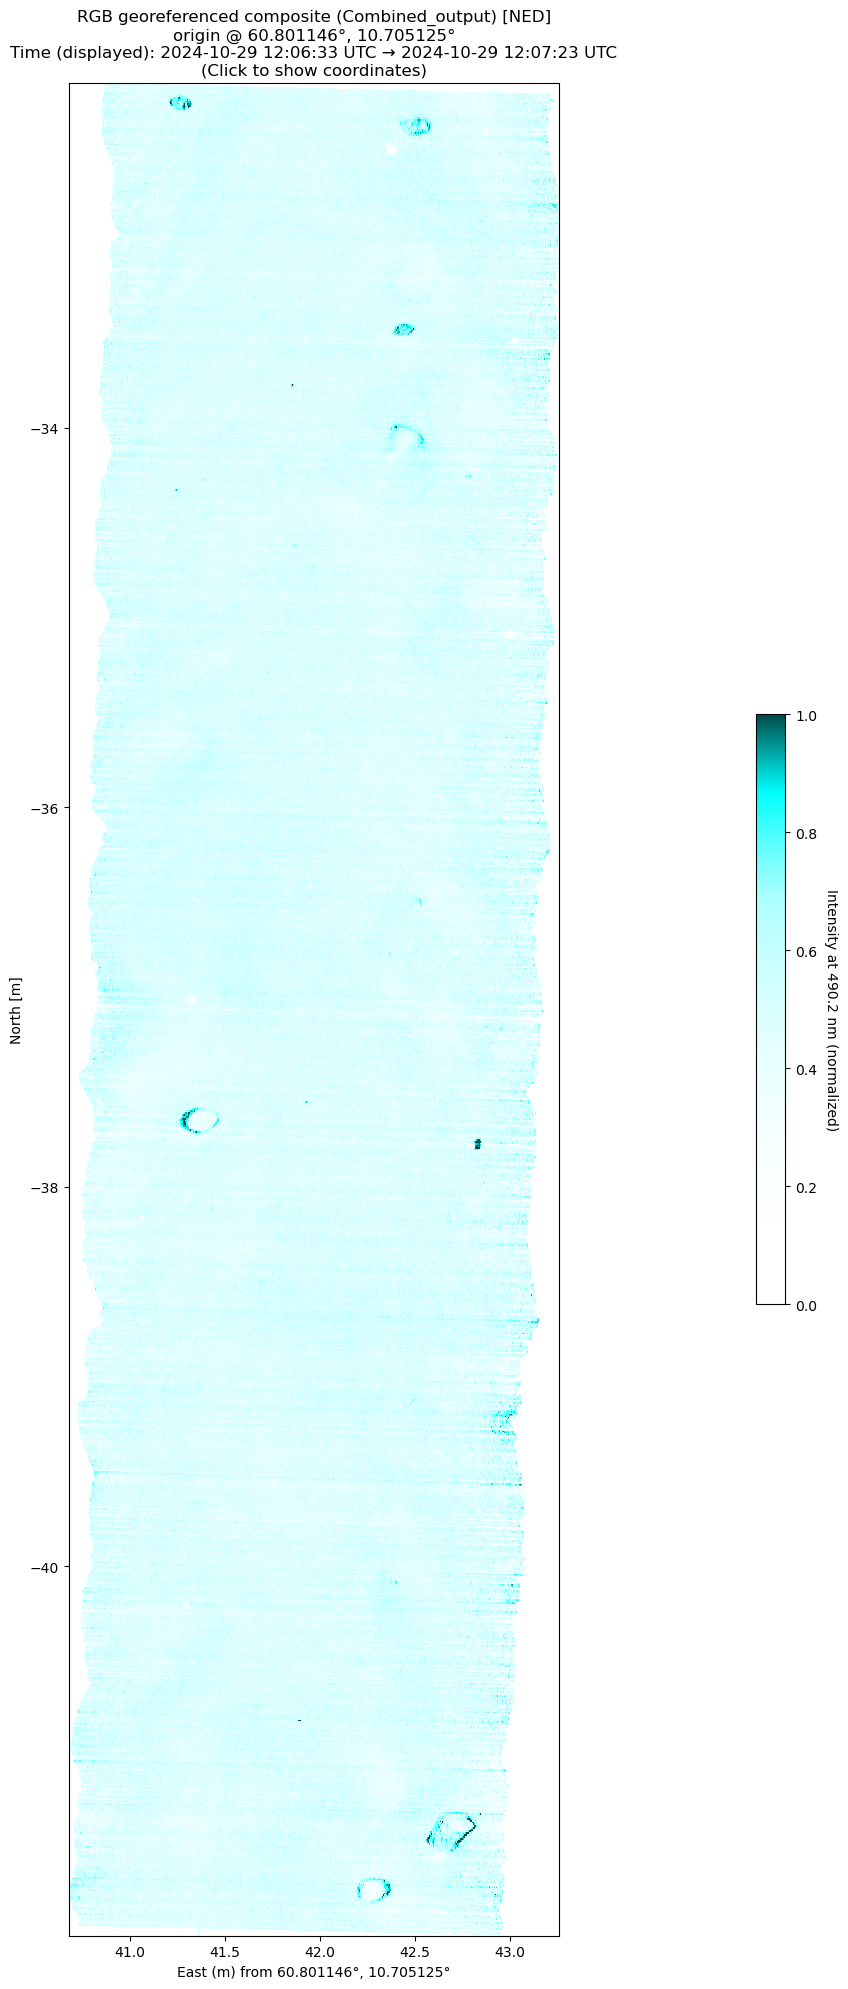

In [ ]:
# 490 nm - Clean image save
plot_georef_clean(
    cube,
    wavelength_target=490,
    save_folder="../images_for_publication/greyscale/057",
    derivative_order=0,
    vmin=0.0793,
    vmax=0.105,
    display_only_image=True,
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
)

🔧 DEBUG: plot_georef called with use_wavelength_colormap=True, wavelength_colormap_target=500
💡 Interactive mode: Click on the plot to display coordinates


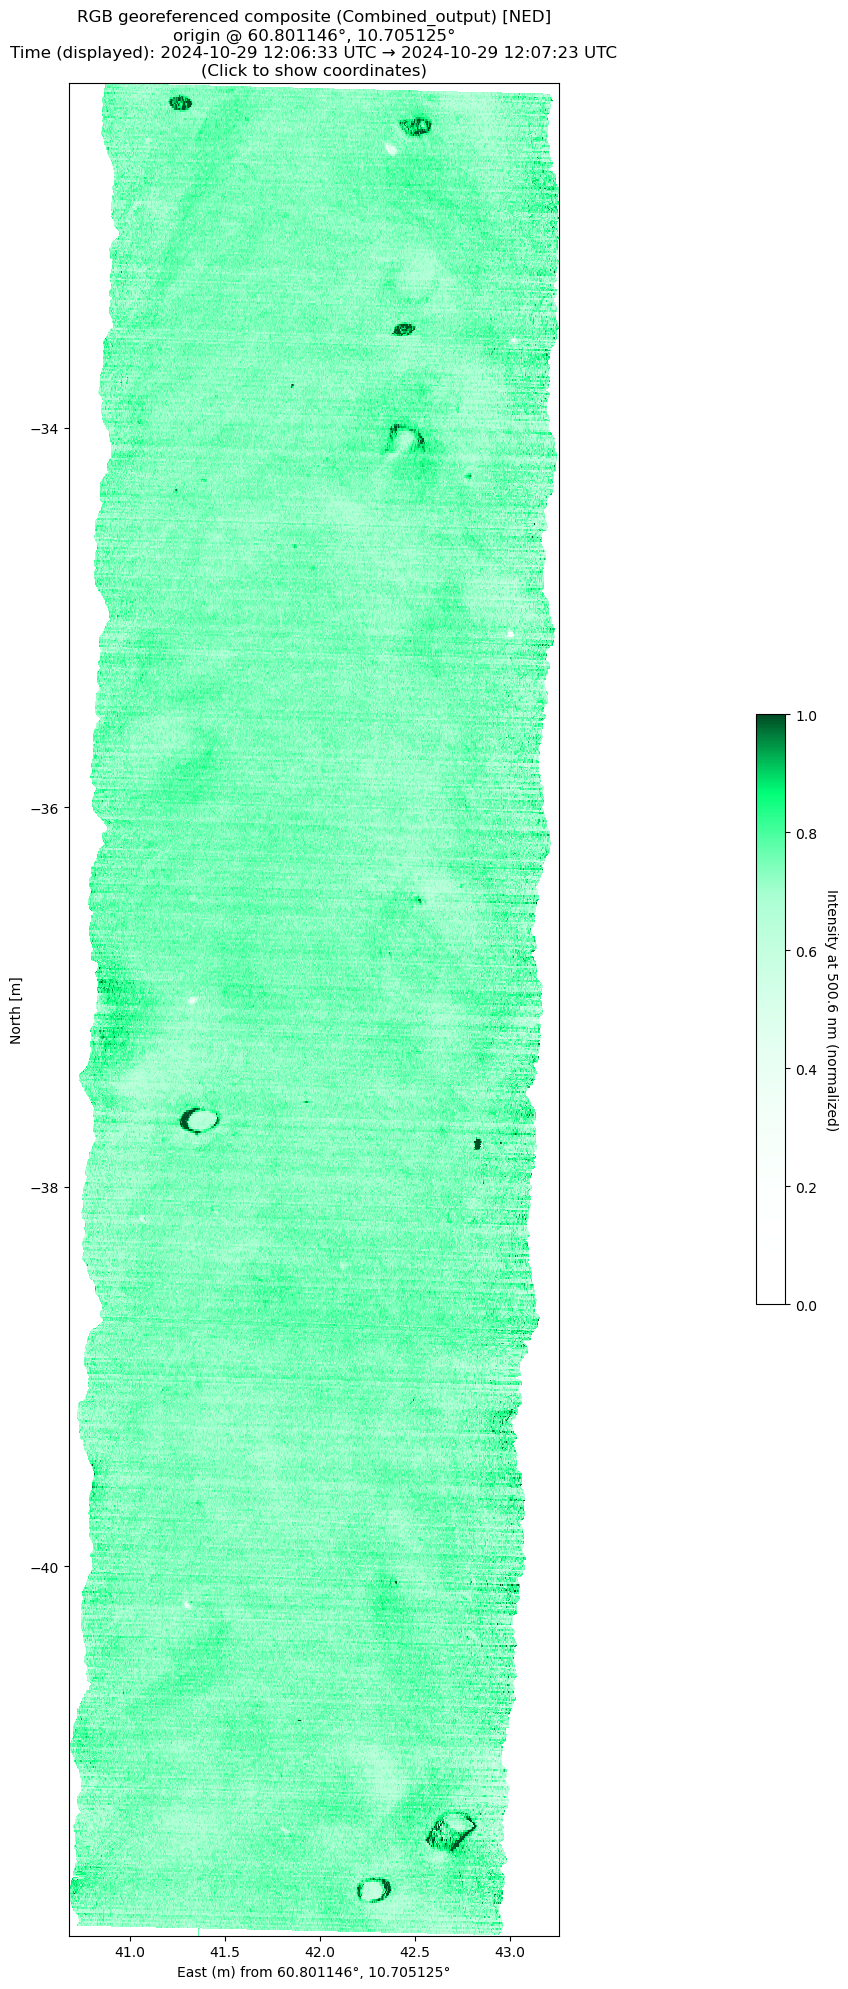

In [ ]:
# cube.plot_georef(
#     use_corrected=True,
#     track_start=config.UHI_TRACK_RANGE[0],
#     track_end=config.UHI_TRACK_RANGE[1],
#     use_wavelength_colormap=True,
#     wavelength_colormap_target=500,
#     # vmin=0.09,
#     # vmax=0.15,
#     # make it use the same minmax as the other greyscales
#     # vmin=0.0855,
#     # vmax=0.095,
#     vmin=0.070832,
#     # vmax = 0.100055,
#     vmax=0.099055,
#     # Let it auto-compute to see actual data range
#     colorbar_fraction=0.006,  # Width
#     colorbar_pad=0.04,  # Padding (now works!)
#     colorbar_shrink=0.5,  # Height (now works!)
#     figsize=(50, 20),
# )

🔧 DEBUG: plot_georef called with use_wavelength_colormap=True, wavelength_colormap_target=610
💡 Interactive mode: Click on the plot to display coordinates


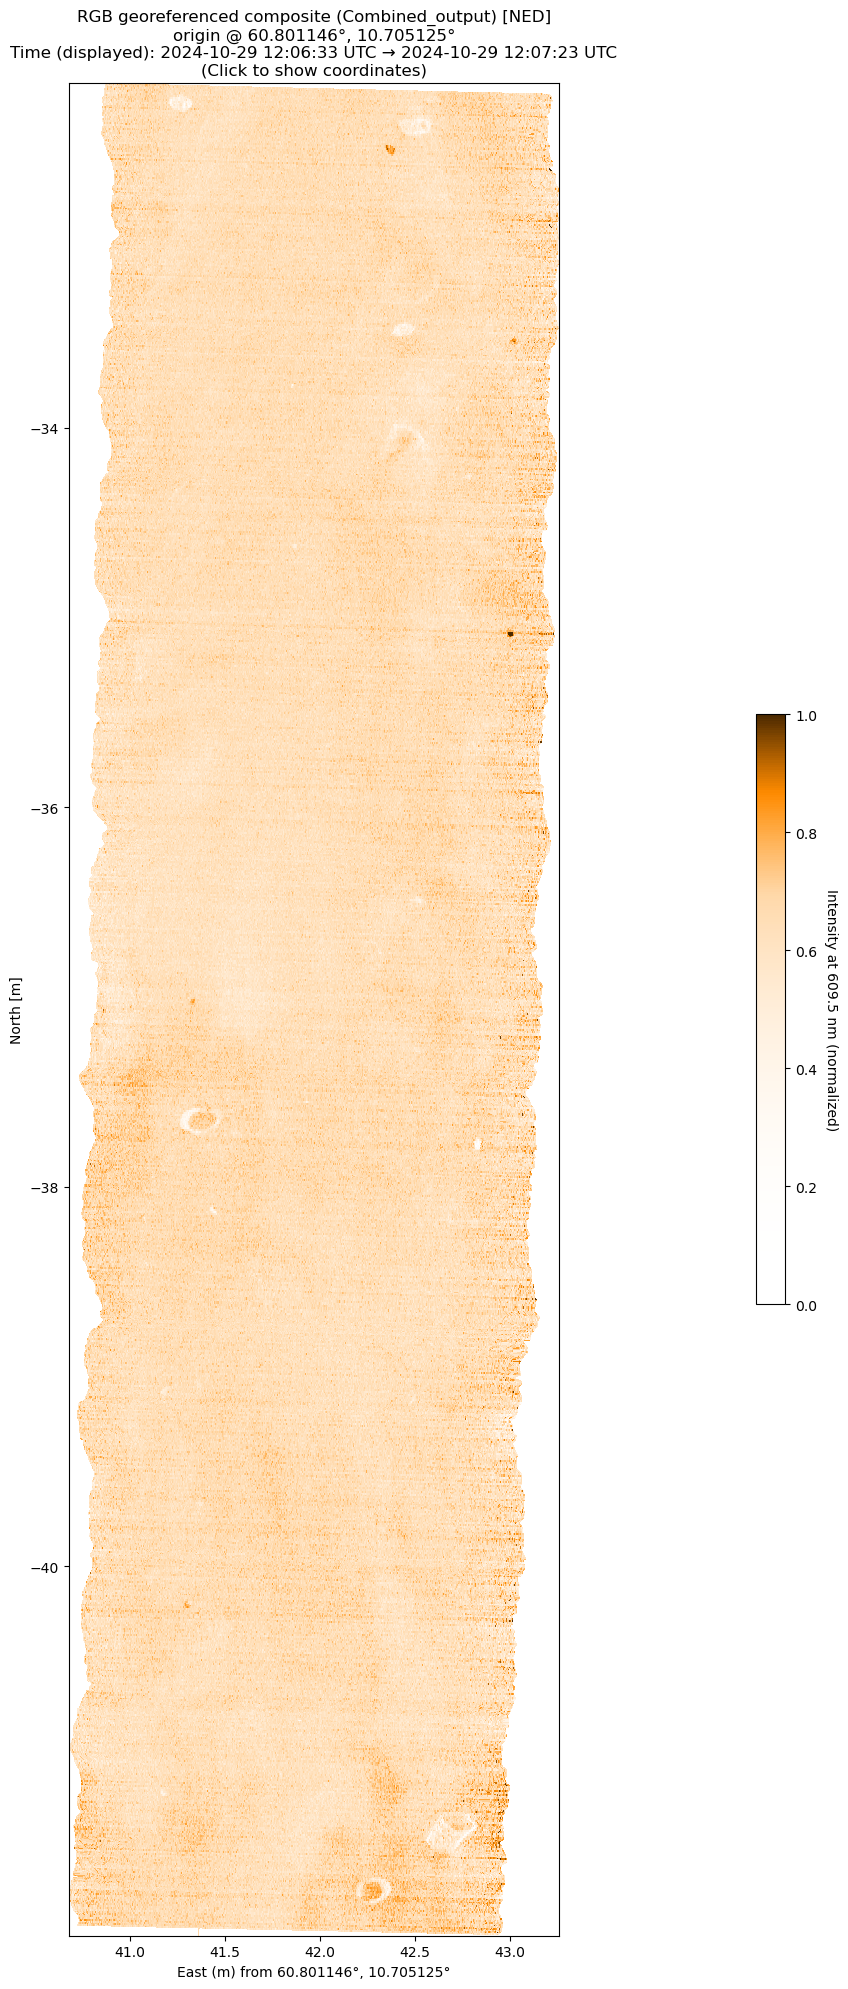

In [ ]:
# 610 nm - Clean image save
plot_georef_clean(
    cube,
    wavelength_target=610,
    save_folder="../images_for_publication/greyscale/057",
    derivative_order=0,
    vmin=0.0855,
    vmax=0.095,
    display_only_image=True,
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
)

# 📖 Methods Documentation: Wavelength-Specific Greyscale Image Generation

---

## Overview

This notebook generates **wavelength-specific greyscale images** from hyperspectral datacubes to visualize seafloor features at precise spectral channels. Unlike RGB composites, single-wavelength images reveal material-specific absorption/reflection patterns, enabling identification of munitions, rocks, and substrate types based on spectral signatures.

**Key Features:**
1. Extract single-wavelength "slices" from hyperspectral cube
2. Generate perceptually-accurate greyscale using wavelength-specific colormaps
3. Apply spectral derivatives to enhance edges and gradients
4. Create cropped region-of-interest (ROI) images around targets
5. Optimize color scales for feature detection

---

## Section 1: Data Preparation

### 1.1 Multi-File Hyperspectral Loading

**Purpose:** Load complete transect from multiple HDF5 files for full spatial coverage.

**Data Source:**
- **Transect:** 028 (5 sequential files)
- **Files:**
  ```python
  files = [
      "rad_uhi_20241029_125028_1",
      "rad_uhi_20241029_125028_2",
      "rad_uhi_20241029_125028_3",
      "rad_uhi_20241029_125028_4",
      "rad_uhi_20241029_125028_5"
  ]
  ```
- **Combined Dimensions:** $T_{\text{total}} \times S \times B$ where tracks concatenated

**Loading Process:**
```python
transect = load_transect(config.TRANSECT_028_OUTPUT)
cube = transect.select_files(files)
```

**Data Structure After Concatenation:**
- `cube.data`: Combined radiance $\mathbf{L} \in \mathbb{R}^{T \times 968 \times 210}$
- `cube.file_boundaries`: Track indices where files join
- `cube.wavelengths`: Consistent across all files (490–700 nm after filtering)

---

### 1.2 Preprocessing Pipeline

**Step 1: Illumination Correction**
```python
cube.apply_illumination_correction_v2(window_size=500)
```
Removes along-track illumination gradient (same as notebooks 4 & 6).

**Step 2: Spectral Smoothing**
```python
cube.apply_spectral_smoothing(method="gaussian", gaussian_sigma=5.0)
```

**Purpose:** Reduce spectral noise while preserving spectral features.

**Gaussian Smoothing (Spectral Domain):**

For each spatial pixel $(t, s)$, smooth across wavelength dimension:
$$
L_{\text{smooth}}(t, s, \lambda_i) = \sum_{j} L(t, s, \lambda_j) \cdot \exp\left(-\frac{(\lambda_i - \lambda_j)^2}{2\sigma^2}\right)
$$

**Parameters:**
- `gaussian_sigma=5.0` → Standard deviation in wavelength indices (not nm)
- Kernel width ≈ $\pm 3\sigma = \pm 15$ wavelength samples
- Preserves spectral shape while reducing per-band noise

**Step 3: Wavelength Filtering**
```python
cube.apply_wavelength_filter(wavelength_range=(490, 700))
```
Keep only visible underwater spectrum (210 bands).

**Step 4: L2 Spectral Normalization**
```python
cube.apply_spectral_normalization(method="l2")
```

**Purpose:** Normalize spectral vectors to unit length for illumination-invariant features.

**L2 Normalization:**

For each spatial pixel, normalize spectrum to unit Euclidean norm:
$$
\mathbf{L}_{\text{norm}}(t, s) = \frac{\mathbf{L}(t, s)}{||\mathbf{L}(t, s)||_2}
$$

where $||\mathbf{L}||_2 = \sqrt{\sum_{\lambda} L^2(t,s,\lambda)}$

**Effect:**
- Removes overall brightness variations
- Preserves spectral **shape** (relative band intensities)
- Makes spectra comparable regardless of depth or illumination
- Each pixel's spectrum is a unit vector in 210-dimensional space

**Why L2 Instead of Other Methods:**
- **vs. MinMax:** Preserves spectral relationships (doesn't squeeze to [0,1])
- **vs. Z-score:** Handles low-signal pixels better (no division by std=0)
- **vs. Mean-relative:** More robust to outlier bands

---

## Section 2: Wavelength-Specific Colormap Generation

### 2.1 Physical Color Representation

**Purpose:** Create perceptually-accurate colormaps that represent actual wavelength colors.

**Wavelength-to-RGB Conversion:**

Uses CIE 1931 color matching functions to convert wavelength to display RGB:

For wavelength $\lambda$ (nm):
1. Lookup CIE XYZ tristimulus values: $X(\lambda), Y(\lambda), Z(\lambda)$
2. Transform to sRGB:
   $$
   \begin{bmatrix} R \\ G \\ B \end{bmatrix} = \mathbf{M}_{\text{XYZ→RGB}} \begin{bmatrix} X \\ Y \\ Z \end{bmatrix}
   $$
3. Apply gamma correction: $R' = R^{1/2.2}$ (and G, B)

**Example Colors:**
- **490 nm:** Cyan-blue $(R=0.0, G=0.88, B=1.0)$
- **610 nm:** Orange $(R=1.0, G=0.65, B=0.0)$
- **677 nm:** Deep red $(R=1.0, G=0.0, B=0.0)$

---

### 2.2 Non-Linear Colormap Construction

**Purpose:** Create greyscale ramp from white → wavelength color → dark, with perceptually-optimized contrast.

**Traditional Linear Mapping (Problem):**

Linear intensity-to-color mapping:
$$
\text{Color}(I) = (1-I) \cdot \text{white} + I \cdot \text{wavelength\_color}
$$

**Issues:**
- Too much white at low intensities (features washed out)
- Too little contrast in mid-range (hard to distinguish features)
- Rapid transition to dark at high intensities

**Non-Linear Power Curve (Solution):**

Apply power transform to intensity before color mapping:
$$
I' = I^p
$$

where $p=2.5$ (tunable parameter).

**Effect:**
- **Low values ($I < 0.4$):** Slow transition, stays white longer (reduces noise)
- **Mid values ($0.4 < I < 0.7$):** Fast transition, better feature contrast
- **High values ($I > 0.7$):** Gradual darkening (smooth saturation)

**Color Stops:**

Colormap interpolates through 4 key colors:
1. **White** $(1.0, 1.0, 1.0)$ at position 0.0
2. **Light color** $(2/3 \text{ white} + 1/3 \text{ wavelength})$ at position 0.4
3. **Bright wavelength** (pure color) at position 0.7
4. **Dark wavelength** $(\text{wavelength} \times 0.3)$ at position 1.0

**Implementation:**
```python
def create_wavelength_colormap_nonlinear(wavelength, darkness_factor=0.3):
    wl_rgb = wavelength_to_rgb(wavelength)
    white = (1.0, 1.0, 1.0)
    light_color = ((c + 2*1.0)/3 for c in wl_rgb)
    bright_color = wl_rgb
    dark_color = (c * darkness_factor for c in wl_rgb)
    
    # Power curve positions
    power = 2.5
    nonlinear_positions = linear_positions ** power
    
    # Interpolate colors based on power curve
    # ... (see notebook for full code)
```

**Tuning Parameter:**
- $p=2.0$: More linear (less contrast)
- $p=2.5$: **Optimal** (balanced)
- $p=3.0$: More contrast in middle (may exaggerate features)

---

## Section 3: Cropped Region-of-Interest (ROI) Generation

### 3.1 ROI Specification

**Purpose:** Generate high-resolution images of specific targets for detailed analysis.

**ROI Definition:**
```python
crop_regions = [
    {"track": 5160, "slit": 613, "label": "Bomb 1"},
    {"track": 1258, "slit": 250, "label": "Bomb 2"},
    {"track": 5592, "slit": 700, "label": "Bomb 3"},
    {"track": 717, "slit": 385, "label": "Dark pits"},
    {"track": 4026, "slit": 582, "label": "Between 1-2"}
]
```

**Coordinates:**
- `track`: Along-flight position (pixel index)
- `slit`: Across-swath position (pixel index)
- `label`: Human-readable target description

**Cropping Parameters:**
- `crop_width=500`: Total width in pixels (250 on each side of center)
- `crop_aspect_ratio=4`: Height = width / 4 (creates wide rectangular crops)
- Crop dimensions: 500 × 125 pixels (width × height)

---

### 3.2 Crop Extraction Algorithm

**Center Crop:**

For center $(t_c, s_c)$ and width $w$:

$$
\begin{aligned}
t_{\text{min}} &= t_c - w/2 \\
t_{\text{max}} &= t_c + w/2 \\
s_{\text{min}} &= s_c - w/(2 \cdot r_{\text{aspect}}) \\
s_{\text{max}} &= s_c + w/(2 \cdot r_{\text{aspect}})
\end{aligned}
$$

where $r_{\text{aspect}}=4$ is aspect ratio.

**Boundary Handling:**

If crop extends beyond image bounds:
```python
t_min = max(0, t_min)
t_max = min(T_total, t_max)
s_min = max(0, s_min)
s_max = min(S_max, s_max)
```

**Extract Subarray:**
```python
crop_data = cube.data[t_min:t_max, s_min:s_max, wavelength_idx]
```

Returns 2D array at specified wavelength.

---

### 3.3 Multiple ROI Visualization

**Function:** `plot_multiple_crops()`

**Purpose:** Generate consistent greyscale images across multiple targets.

**Key Parameters:**

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `wavelength_target` | 490, 610, 660, 677 | Wavelength to visualize (nm) |
| `derivative_order` | 0, 1, 2 | Spectral derivative order |
| `vmin, vmax` | Data-dependent | Color scale limits |
| `crop_width` | 500 | Crop width (pixels) |
| `crop_aspect_ratio` | 4 | Width:height ratio |
| `display_aspect_ratio` | 4.0 | Matplotlib display stretch |
| `flip_axes` | True | Transpose for horizontal layout |
| `flip_horizontal` | True | Mirror for consistent orientation |
| `use_wavelength_colormap` | True | Physical wavelength colors |
| `colorbar_orientation` | "horizontal" | Colorbar below image |

**Example Usage:**
```python
plot_multiple_crops(
    cube,
    crop_regions,
    wavelength_target=677,  # Deep red
    derivative_order=0,     # Raw intensity
    vmin=0.086,
    vmax=0.108,
    colorbar_orientation='horizontal'
)
```

**Output:**
- One figure per ROI
- Consistent color scaling across all targets
- Wavelength-specific colormap (red for 677nm, cyan for 490nm, etc.)
- Horizontal colorbar for compact layout

---

## Section 4: Spectral Derivative Enhancement

### 4.1 Derivative Computation

**Purpose:** Enhance edges and gradients by computing spatial derivatives of spectral intensity.

**Derivative Orders:**

**Order 0 (Raw Intensity):**
$$
D^{(0)}(x, y) = I(x, y)
$$
Direct intensity values, no enhancement.

**Order 1 (First Derivative):**
$$
D^{(1)}(x, y) = \frac{\partial I}{\partial x} \approx I(x+1, y) - I(x-1, y)
$$

Central difference approximation.

**Order 2 (Second Derivative, Laplacian):**
$$
D^{(2)}(x, y) = \nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}
$$

**Implementation:**
```python
def compute_derivative(image, order, window=2):
    if order == 0:
        return image
    elif order == 1:
        # Sobel gradient magnitude
        gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=window)
        gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=window)
        return np.sqrt(gx**2 + gy**2)
    elif order == 2:
        # Laplacian
        return cv2.Laplacian(image, cv2.CV_64F, ksize=window)
```

**Parameters:**
- `derivative_order`: 0, 1, or 2
- `derivative_window`: Kernel size (typically 2–5 pixels)

---

### 4.2 Physical Interpretation

**Order 0 (Raw Intensity):**
- Shows absolute brightness
- Bright = shallow/elevated/reflective
- Dark = deep/shadowed/absorptive
- **Use for:** Material identification, depth estimation

**Order 1 (Gradient Magnitude):**
- Shows rate of intensity change
- High values = sharp edges, boundaries
- Low values = smooth regions
- **Use for:** Edge detection, feature boundaries, munition outlines

**Order 2 (Laplacian):**
- Shows curvature/concavity
- Positive = convex features (bumps, mounds)
- Negative = concave features (pits, valleys)
- Zero-crossing = inflection points (edges)
- **Use for:** Blob detection, texture analysis

**Typical Applications:**

| Order | Wavelength | Application |
|-------|------------|-------------|
| 0 | 677 nm (red) | Surface features, shallow objects |
| 0 | 490 nm (blue) | Deep features, water column |
| 1 | 660 nm | Munition edges, substrate boundaries |
| 1 | 610 nm | Rock outlines, texture transitions |
| 2 | Any | Convexity analysis, bump detection |

---

### 4.3 Color Scale Optimization

**Purpose:** Determine optimal vmin/vmax for feature visualization.

**Manual Tuning (Used in Notebook):**

Empirically determined ranges for each wavelength and derivative order:

```python
# Order 0 (raw intensity) at 677 nm
vmin=0.086, vmax=0.108  # Tight range for subtle features

# Order 1 (gradient) at 660 nm
vmin=-0.000365, vmax=0.000427  # Asymmetric (directional edges)

# Order 0 at 490 nm (blue)
vmin=0.0793, vmax=0.105  # Wider range (more signal)

# Order 0 at 610 nm (orange)
vmin=0.0855, vmax=0.095  # Medium range
```

**Optimization Strategy:**

1. **Compute percentiles:**
   ```python
   vmin = np.percentile(crop_data, 2)   # 2nd percentile
   vmax = np.percentile(crop_data, 98)  # 98th percentile
   ```

2. **Adjust for symmetry (derivatives):**
   ```python
   if derivative_order > 0:
       vmax_abs = max(abs(vmin), abs(vmax))
       vmin, vmax = -vmax_abs, vmax_abs
   ```

3. **Fine-tune manually** based on feature visibility

**Effect of Tight Range:**
- Increases contrast in narrow intensity band
- Saturates outliers (clips to white/black)
- Better for subtle features

**Effect of Wide Range:**
- Preserves full dynamic range
- Lower contrast
- Better for comparing absolute values

---

## Section 5: Summary

### Image Generation Pipeline

**1. Data Loading & Preprocessing**
   - Load multi-file transect (028: 5 files combined)
   - Illumination correction (window=500)
   - Spectral smoothing (Gaussian σ=5.0)
   - Wavelength filter (490–700 nm)
   - L2 spectral normalization (unit vector per pixel)

**2. Wavelength Selection**
   - Red (677 nm): Surface sensitivity, strong absorption
   - Orange (610 nm): Intermediate depth
   - Red-orange (660 nm): Edge detection
   - Blue-cyan (490 nm): Deep penetration

**3. Colormap Generation**
   - Physical wavelength colors (CIE 1931 RGB conversion)
   - Non-linear power curve (p=2.5) for perceptual optimization
   - White → light color → bright → dark progression
   - Better contrast than linear mapping

**4. ROI Extraction**
   - Define target centers (track, slit coordinates)
   - Extract 500×125 pixel crops (aspect=4)
   - Flip and transpose for consistent layout

**5. Derivative Enhancement (Optional)**
   - Order 0: Raw intensity
   - Order 1: Gradient magnitude (edges)
   - Order 2: Laplacian (curvature)

**6. Visualization**
   - Consistent color scaling across targets
   - Horizontal colorbar placement
   - Multiple wavelengths for comparison

### Key Parameters

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `gaussian_sigma` | 5.0 | Spectral smoothing strength |
| `normalization_method` | "l2" | Illumination invariance |
| `power` | 2.5 | Colormap non-linearity |
| `crop_width` | 500 px | ROI width |
| `crop_aspect_ratio` | 4 | Width:height |
| `derivative_window` | 2 | Derivative kernel size |

### Optimal Color Ranges (Empirical)

**Raw Intensity (Order 0):**
- 677 nm: vmin=0.086, vmax=0.108
- 610 nm: vmin=0.0855, vmax=0.095
- 490 nm: vmin=0.0793, vmax=0.105

**Gradient (Order 1):**
- 660 nm: vmin=-0.000365, vmax=0.000427

### Applications

**Material Identification:**
- Different materials show distinct spectral signatures
- Red channels reveal surface features
- Blue channels penetrate deeper

**Target Detection:**
- Munitions appear as bright spots at 677 nm (elevated/shallow)
- Dark pits visible at all wavelengths
- Gradient images highlight edges

**Multi-Wavelength Comparison:**
- Compare red vs. blue response
- Identify depth-dependent features
- Validate classification results

---

## Executive Summary: Wavelength-Specific Greyscale Generation

### What This Notebook Does

Generates high-quality greyscale images at specific wavelengths from hyperspectral datacubes to visualize material-specific spectral signatures. Uses perceptually-optimized colormaps with physical wavelength colors and optional spatial derivative enhancement.

### The 6-Step Workflow

**1. Load Multi-File Transect**
   - Transect 028: 5 files concatenated
   - Full spatial coverage
   - Track file boundaries for reference

**2. Preprocess Spectral Data**
   - Illumination correction (removes sun angle effects)
   - Gaussian smoothing (σ=5.0, reduces spectral noise)
   - Wavelength filter (490–700 nm visible range)
   - L2 normalization (illumination-invariant spectra)

**3. Select Target Wavelengths**
   - **677 nm (deep red):** Surface features, shallow sensitivity
   - **610 nm (orange):** Intermediate depth, substrate color
   - **660 nm (red-orange):** Edge detection
   - **490 nm (cyan):** Deep penetration, water column

**4. Generate Perceptual Colormaps**
   - Convert wavelength to physical RGB (CIE 1931)
   - Apply non-linear power curve (p=2.5)
   - White → light → bright → dark progression
   - Better contrast than linear mapping

**5. Extract Region-of-Interest Crops**
   - Define centers around targets (bombs, pits, features)
   - 500×125 pixel crops (aspect ratio 4:1)
   - Consistent orientation (flip/transpose)

**6. Apply Optional Derivative Enhancement**
   - **Order 0:** Raw intensity (material ID)
   - **Order 1:** Gradient (edge detection)
   - **Order 2:** Laplacian (curvature/bumps)

### Key Technical Innovations

**Non-Linear Colormap:**
- Traditional linear mapping washes out features
- Power curve (x^2.5) optimizes perceptual contrast
- Stays white longer (reduces noise)
- Fast mid-range transition (better features)
- Gradual darkening (smooth saturation)

**L2 Spectral Normalization:**
- Makes spectra comparable across depths
- Removes overall brightness (preserves shape)
- Each pixel = unit vector in 210D space
- Better than MinMax or Z-score for underwater data

**Physical Wavelength Colors:**
- Colormap matches actual light color
- Red channel displays in red, blue in cyan/blue
- Intuitive interpretation
- Scientifically accurate

### Typical Results

**Munition at 677 nm (red):**
- Bright spot (elevated, shallow)
- Circular or elongated shape
- Distinct from surrounding seafloor
- Gradient shows sharp edges

**Munition at 490 nm (blue):**
- Less contrast (deeper penetration)
- Water column effects visible
- Useful for depth estimation

**Gradient Image (Order 1, 660 nm):**
- Outline of munition visible as bright ring
- Interior relatively flat (low gradient)
- Background noise suppressed

**Pit/Depression:**
- Dark at all wavelengths
- Negative Laplacian (concave)
- Gradient highlights boundary

### Interpretation Guide

**Brightness Patterns (Order 0):**
- Bright at 677nm, dim at 490nm → Shallow feature
- Dim at 677nm, bright at 490nm → Deep feature or water
- Bright at all wavelengths → Highly reflective (metal?)
- Dim at all wavelengths → Highly absorptive (dark sediment)

**Gradient Patterns (Order 1):**
- Strong gradient ring → Sharp-edged object (munition, rock)
- Weak gradient → Smooth transition (natural feature)
- Asymmetric gradient → Directional feature (elongated object)

**Laplacian Patterns (Order 2):**
- Positive center, negative surround → Bump (convex)
- Negative center, positive surround → Pit (concave)
- Zero with gradient → Edge/boundary

### Why This Matters

- **Material discrimination** impossible with RGB composites alone
- **Spectral signatures** reveal material properties
- **Derivative enhancement** highlights features invisible in raw data
- **Consistent visualization** enables quantitative comparison
- **Physical colors** aid intuitive interpretation
- **Paper-ready figures** for publication

---